# Лабораторная работа №2: Обнаружение аномалий и выбросов
в данных

### Задание 1. Загрузка и профилирование данных

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

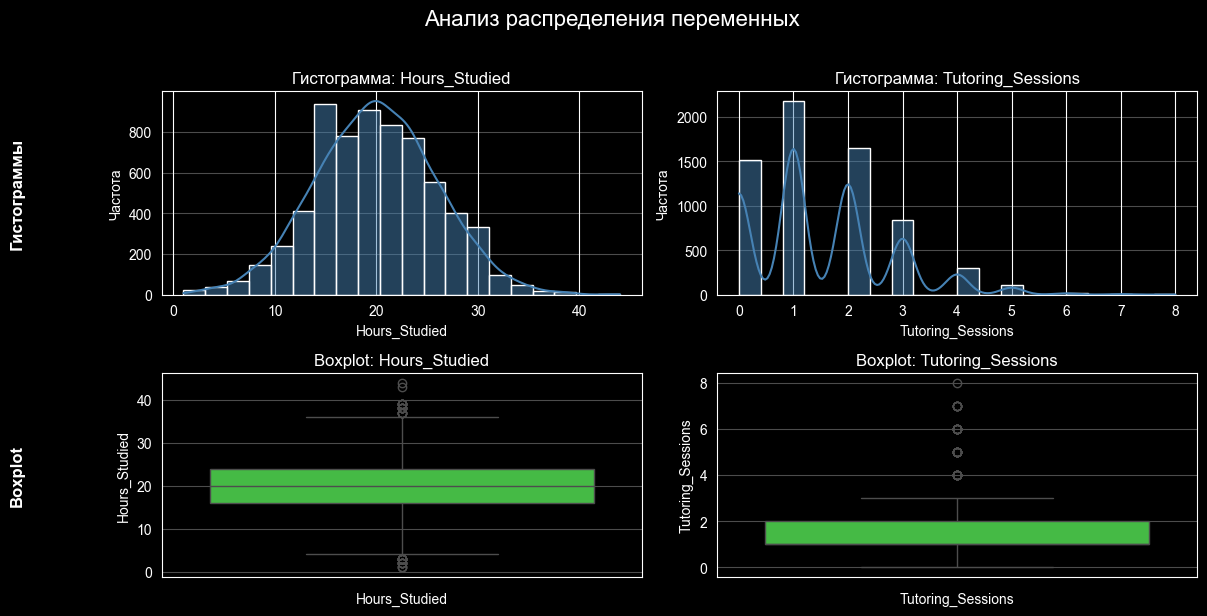

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/StudentPerformanceFactors.csv')

df.info()
print(df.describe())

print('Количество пропусков по столбцам:')
print(df.isnull().sum())

print('Диапазон числовых значение:')
number_col = df.select_dtypes(include='number')
result_range = pd.DataFrame({
    'Минимальное: ' : number_col.min(),
    'Максимальное: ' : number_col.max(),
    'Диапазон: ' : number_col.max() - number_col.min()
})
print(result_range)

def find_extremes_percentile(data, column, percentile=1):
    lower_thresh = data[column].quantile(percentile / 100)
    upper_thresh = data[column].quantile(1 - percentile / 100)

    extremes = data[(data[column] <= lower_thresh) | (data[column] >= upper_thresh)]
    return  extremes, lower_thresh, upper_thresh
for column in number_col.columns:
    extremes_1, lower_1, upper_1 = find_extremes_percentile(df, column, 1)
    print('Столбец: ', column)
    print(f'Экстремальные (1%): от {lower_1} до {upper_1}')
    print(f"Количество экстремальных значений: {len(extremes_1)}")


number_col_two = ['Hours_Studied', 'Tutoring_Sessions']
n = len(number_col_two)

fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(12, 6))

for idx, col in enumerate(number_col_two):
    sns.histplot(df[col], bins=20, kde=True, color='steelblue', ax=axes[0, idx])
    axes[0, idx].set_title(f'Гистограмма: {col}')
    axes[0, idx].set_xlabel(col)
    axes[0, idx].set_ylabel('Частота')
    axes[0, idx].grid(axis='y', alpha=0.3)

for idx, col in enumerate(number_col_two):
    sns.boxplot(y=df[col], color='limegreen', ax=axes[1, idx])
    axes[1, idx].set_title(f'Boxplot: {col}')
    axes[1, idx].set_xlabel(col)
    axes[1, idx].grid(axis='y', alpha=0.3)

axes[0, 0].text(-0.3, 0.5, 'Гистограммы', transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].text(-0.3, 0.5, 'Boxplot', transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Анализ распределения переменных', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Вывод о возможных выбрасах
1. Hours_Studied:
- Гистограмма: Распределение близко к нормальному, правый хвост тянется до 40+ часов, левый до 0 не включительно, максимальная частота ~15 часах
- Boxplot: Выбросы сверху от ~35 часов, снизу ~5 часов
2. Tutoring_Sessions:
- Гистограмма: Правый хвост тянется до 8 часов, максимальная частота в 1 занятие
- Boxplot: Выбросы сверху от 4 часов, снизу нет выбросов
### Задание 2. Проверка нормальности распределения

Описательные характеристики:
              Строка    Среднее  Медиана  Стандартное отклонение  \
0      Hours_Studied  19.975329     20.0                5.990594   
1  Tutoring_Sessions   1.493719      1.0                1.230570   

   Коэффицент асимметрии  Коэффицент эксцесса  
0               0.013496             0.016849  
1               0.815344             0.642323  


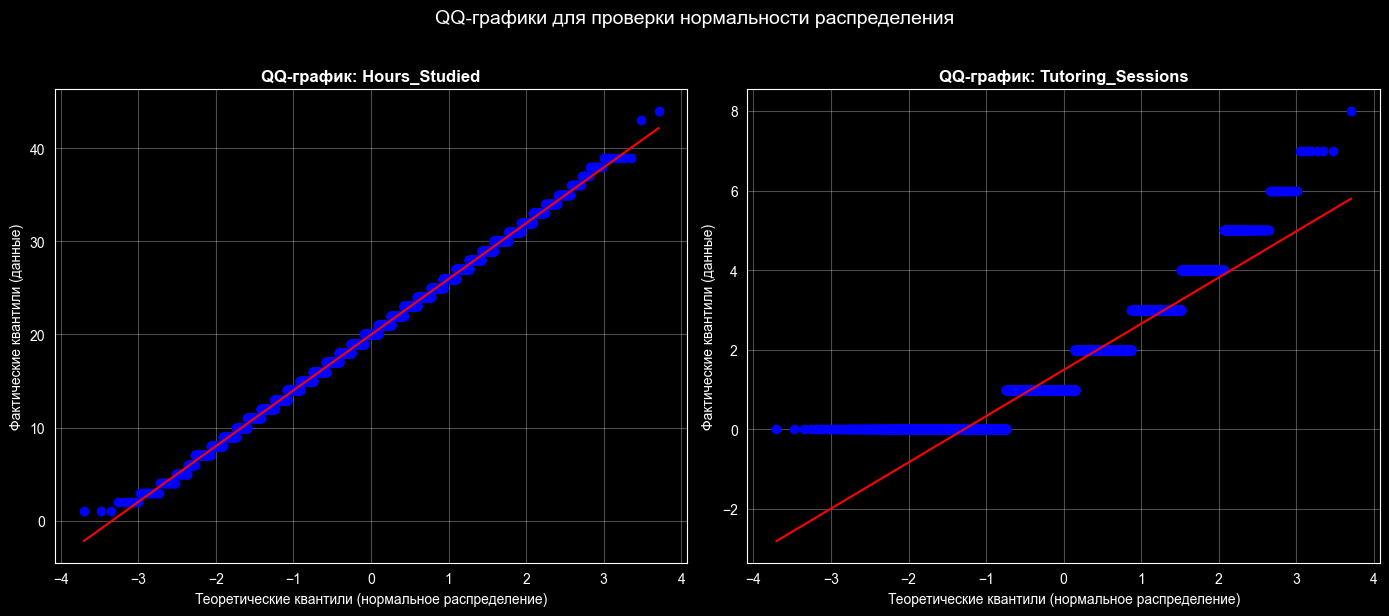

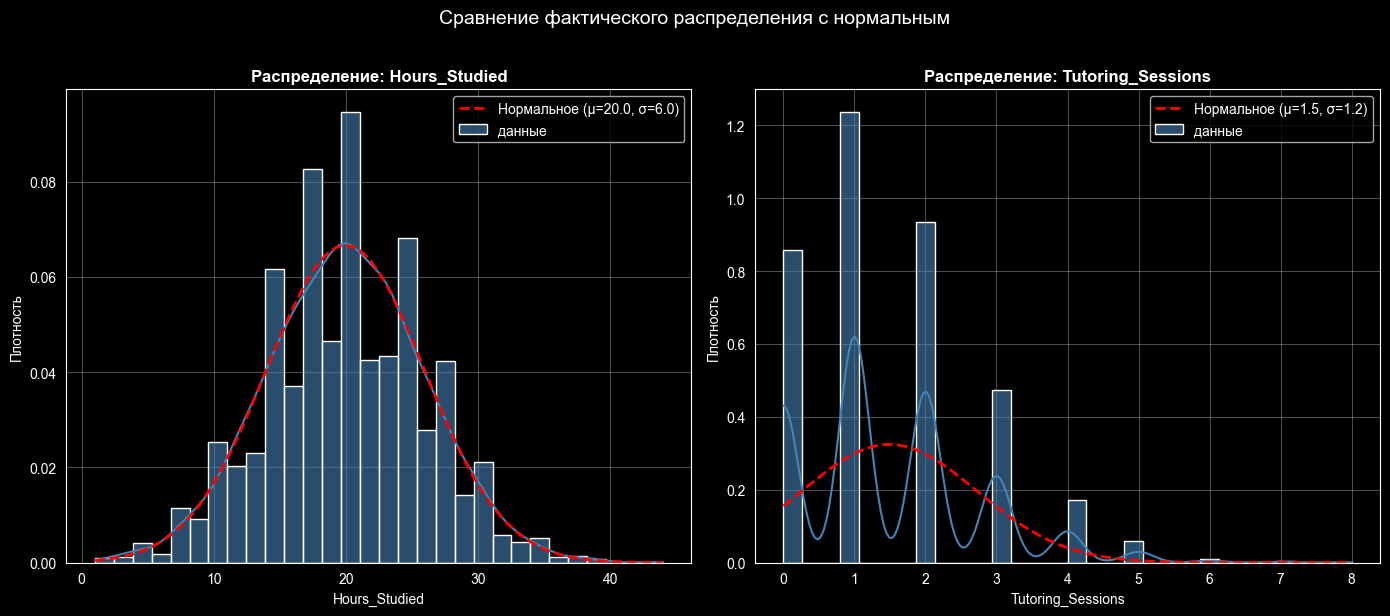

In [2]:
import numpy as np
from scipy import stats

print('Описательные характеристики:')

specifications_result = []
for col in number_col_two:
    specifications_result.append({
        'Строка' : col,
        'Среднее' : df[col].mean(),
        'Медиана' : df[col].median(),
        'Стандартное отклонение' : df[col].std(),
        'Коэффицент асимметрии' : stats.skew(df[col]),
        'Коэффицент эксцесса' : stats.kurtosis(df[col])
    })
print(pd.DataFrame(specifications_result))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, col in enumerate(number_col_two):
    data = df[col].dropna()

    stats.probplot(data, dist="norm", plot=axes[idx])
    axes[idx].set_title(f'QQ-график: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Теоретические квантили (нормальное распределение)', fontsize=10)
    axes[idx].set_ylabel('Фактические квантили (данные)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('QQ-графики для проверки нормальности распределения', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, col in enumerate(number_col_two):
    data = df[col].dropna()

    sns.histplot(data, bins=30, kde=True, stat='density',
                 color='steelblue', alpha=0.6, ax=axes[idx], label='данные')

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    p = stats.norm.pdf(x, mu, sigma)
    axes[idx].plot(x, p, 'r--', linewidth=2, label=f'Нормальное (μ={mu:.1f}, σ={sigma:.1f})')

    axes[idx].set_title(f'Распределение: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Плотность')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Сравнение фактического распределения с нормальным', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##### график Hours_Studied почти совпадает с графиком нормального распределения
##### график Tutoring_Sessions не совпадает с графиком нормального распределения

In [3]:
def shapiro_wilk_test(df, column, alpha=0.05):
    data = df[column].dropna()
    stat, p_value = stats.shapiro(data)
    if p_value > alpha:
        decision = "Не отвергаем H₀"
        conclusion = "Распределение можно считать нормальным"
    else:
        decision = "Отвергаем H₀"
        conclusion = "Распределение не является нормальным"
    return {
        'Строка ': column,
        'Уровень значимости ' : alpha,
        'Статистика W ': stat,
        'p-значение ': p_value,
        'Решение ': decision,
        'Вывод ': conclusion
    }

columns_to_test = ['Hours_Studied', 'Tutoring_Sessions']
results = []
print("критерий Шапиро–Уилка:")
print(f"Гипотезы:")
print(f"  H₀: распределение нормальное")
print(f"  H₁: распределение не нормальное")

for col in columns_to_test:
    results.append(shapiro_wilk_test(df,col,0.05))
print(pd.DataFrame(results))

критерий Шапиро–Уилка:
Гипотезы:
  H₀: распределение нормальное
  H₁: распределение не нормальное
             Строка   Уровень значимости   Статистика W    p-значение   \
0      Hours_Studied                 0.05       0.997433  3.608347e-09   
1  Tutoring_Sessions                 0.05       0.890143  5.091151e-56   

       Решение                                 Вывод   
0  Отвергаем H₀  Распределение не является нормальным  
1  Отвергаем H₀  Распределение не является нормальным  


C:\Users\1\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6607.
  res = hypotest_fun_out(*samples, **kwds)


### Задание 3. Обнаружение выбросов статистическими методами
1. Метод Z-score

Оценка Z-score для Hours_Studied:
0       0.504903
1      -0.162810
2       0.671832
3       1.506473
4      -0.162810
          ...   
6602    0.838760
6603    0.504903
6604    0.004118
6605   -1.665165
6606   -0.830523
Name: Hours_Studied, Length: 6607, dtype: float64
Нижняя граница:  2.0035461865707234
Верхняя граница:  37.94711220604317
Количество выбросов 25 при |Z| > 3


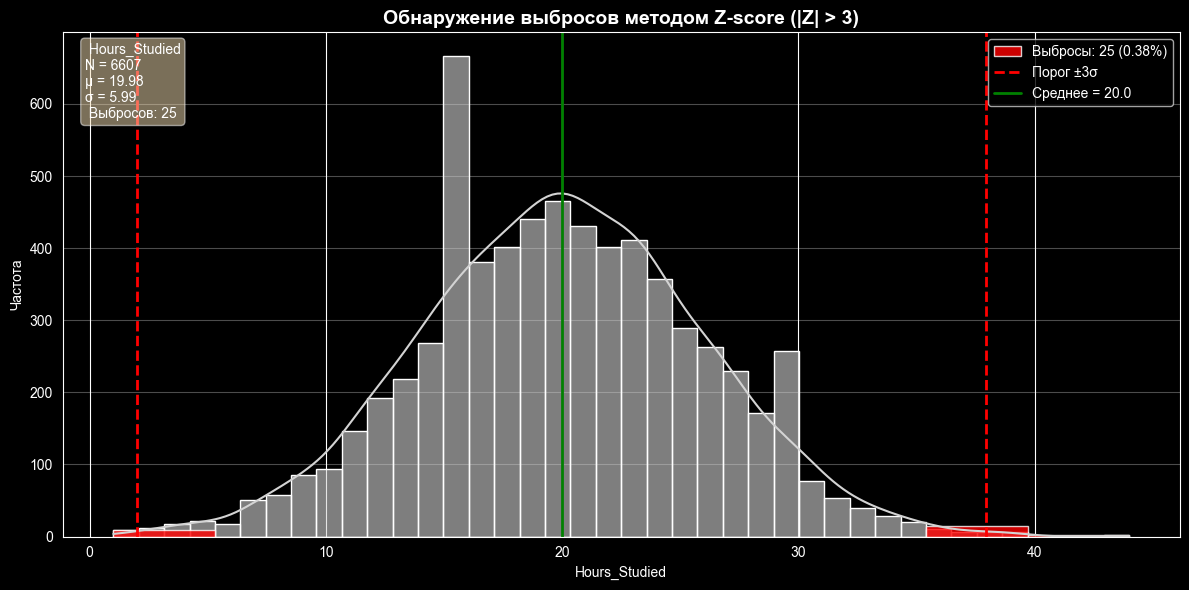

In [4]:
column = 'Hours_Studied'
data = df[column].dropna()
# Формула Z-score: Z = (X - μ) / σ
mean_val = data.mean()
std_val = data.std()

z_scores = (data - mean_val) / std_val
print(f'Оценка Z-score для {column}:')
print(z_scores)

threshold = 3
outliers_mask = np.abs(z_scores) > threshold
outliers_count = outliers_mask.sum()
outliers_percentage = (outliers_count / len(data)) * 100
lower_bound = mean_val - threshold * std_val
upper_bound = mean_val + threshold * std_val

print('Нижняя граница: ', lower_bound)
print('Верхняя граница: ', upper_bound)

print(f'Количество выбросов {outliers_count} при |Z| > 3')

outlier_data = data[outliers_mask]
plt.figure(figsize=(12, 6))

sns.histplot(data, bins=40, kde=True, color='lightgray', alpha=0.6)

if outliers_count > 0:
    plt.hist(outlier_data, bins=10, color='red', alpha=0.8,
             label=f'Выбросы: {outliers_count} ({outliers_percentage:.2f}%)')

plt.axvline(lower_bound, color='red', linestyle='--', linewidth=2,
            label=f'Порог ±3σ')
plt.axvline(upper_bound, color='red', linestyle='--', linewidth=2)
plt.axvline(mean_val, color='green', linestyle='-', linewidth=2,
            label=f'Среднее = {mean_val:.1f}')

stats_text = (f' {column}\n'
              f'N = {len(data)}\n'
              f'μ = {mean_val:.2f}\n'
              f'σ = {std_val:.2f}\n'
              f' Выбросов: {outliers_count}')

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.title(f'Обнаружение выбросов методом Z-score (|Z| > {threshold})',
          fontweight='bold', fontsize=14)
plt.xlabel(column)
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


2. Метод IQR

In [5]:
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

print('Q1: ', Q1)
print('Q3: ', Q3)
print('IQR: ', IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Нижняя граница: ', lower_bound)
print('Верхняя граница: ', upper_bound)

outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f'Выбросов по методу IQR: {len(outliers)}')


Q1:  16.0
Q3:  24.0
IQR:  8.0
Нижняя граница:  4.0
Верхняя граница:  36.0
Выбросов по методу IQR: 43


#### Сравнение
- Z-score: Нижняя граница:  ~2; Верхняя граница:  ~38; Количество выбросов 25 при |Z| > 3
- IQR метод: Нижняя граница:  4.0; Верхняя граница:  36.0; Выбросов по методу IQR: 43
#### сравнительный анализ
1. Z-score если:
- Распределение близко к нормальному
- Нужно стандартизировать данные для машинного обучения
- Минимизировать ложные срабатывания
2. IQR метод если
- Распределение скошено
- Данные содержат экстремальные значения
- Нужен метод, нечувствительный к выбросам

### Задание 4. Метод локальной плотности

In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'exam_score' in numeric_features:
    numeric_features.remove('Exam_Score')

print(f"\n Признаки: {numeric_features}")

X = df[numeric_features].dropna()
print(f"Объём выборки: {len(X)}")

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

print(f"Применён MinMaxScaler [0, 1]")
print(f"Минимум после: {X_scaled.min():.6f}")
print(f"Максимум после: {X_scaled.max():.6f}")
print(f"Среднее после: {X_scaled.mean():.6f}")


 Признаки: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Объём выборки: 6607
Применён MinMaxScaler [0, 1]
Минимум после: 0.000000
Максимум после: 1.000000
Среднее после: 0.413469


### 1 Базовый подход: расстояние до k-го соседа


Euclidean расстояние (k=10):
  Порог: 0.3041
  Аномалий: 331 (5.01%)

Manhattan расстояние (k=10):
  Порог: 0.5885
  Аномалий: 331 (5.01%)

=== Среднее расстояние до k соседей ===
euclidean (k=5): 331 аномалий (5.01%)
manhattan (k=5): 331 аномалий (5.01%)
euclidean (k=7): 331 аномалий (5.01%)
manhattan (k=7): 331 аномалий (5.01%)
euclidean (k=9): 331 аномалий (5.01%)
manhattan (k=9): 331 аномалий (5.01%)
euclidean (k=10): 331 аномалий (5.01%)
manhattan (k=10): 331 аномалий (5.01%)

=== Оценка локальной плотности ===
euclidean (k=5): 331 аномалий (5.01%)
manhattan (k=5): 331 аномалий (5.01%)
euclidean (k=7): 331 аномалий (5.01%)
manhattan (k=7): 331 аномалий (5.01%)
euclidean (k=9): 331 аномалий (5.01%)
manhattan (k=9): 331 аномалий (5.01%)
euclidean (k=10): 331 аномалий (5.01%)
manhattan (k=10): 331 аномалий (5.01%)


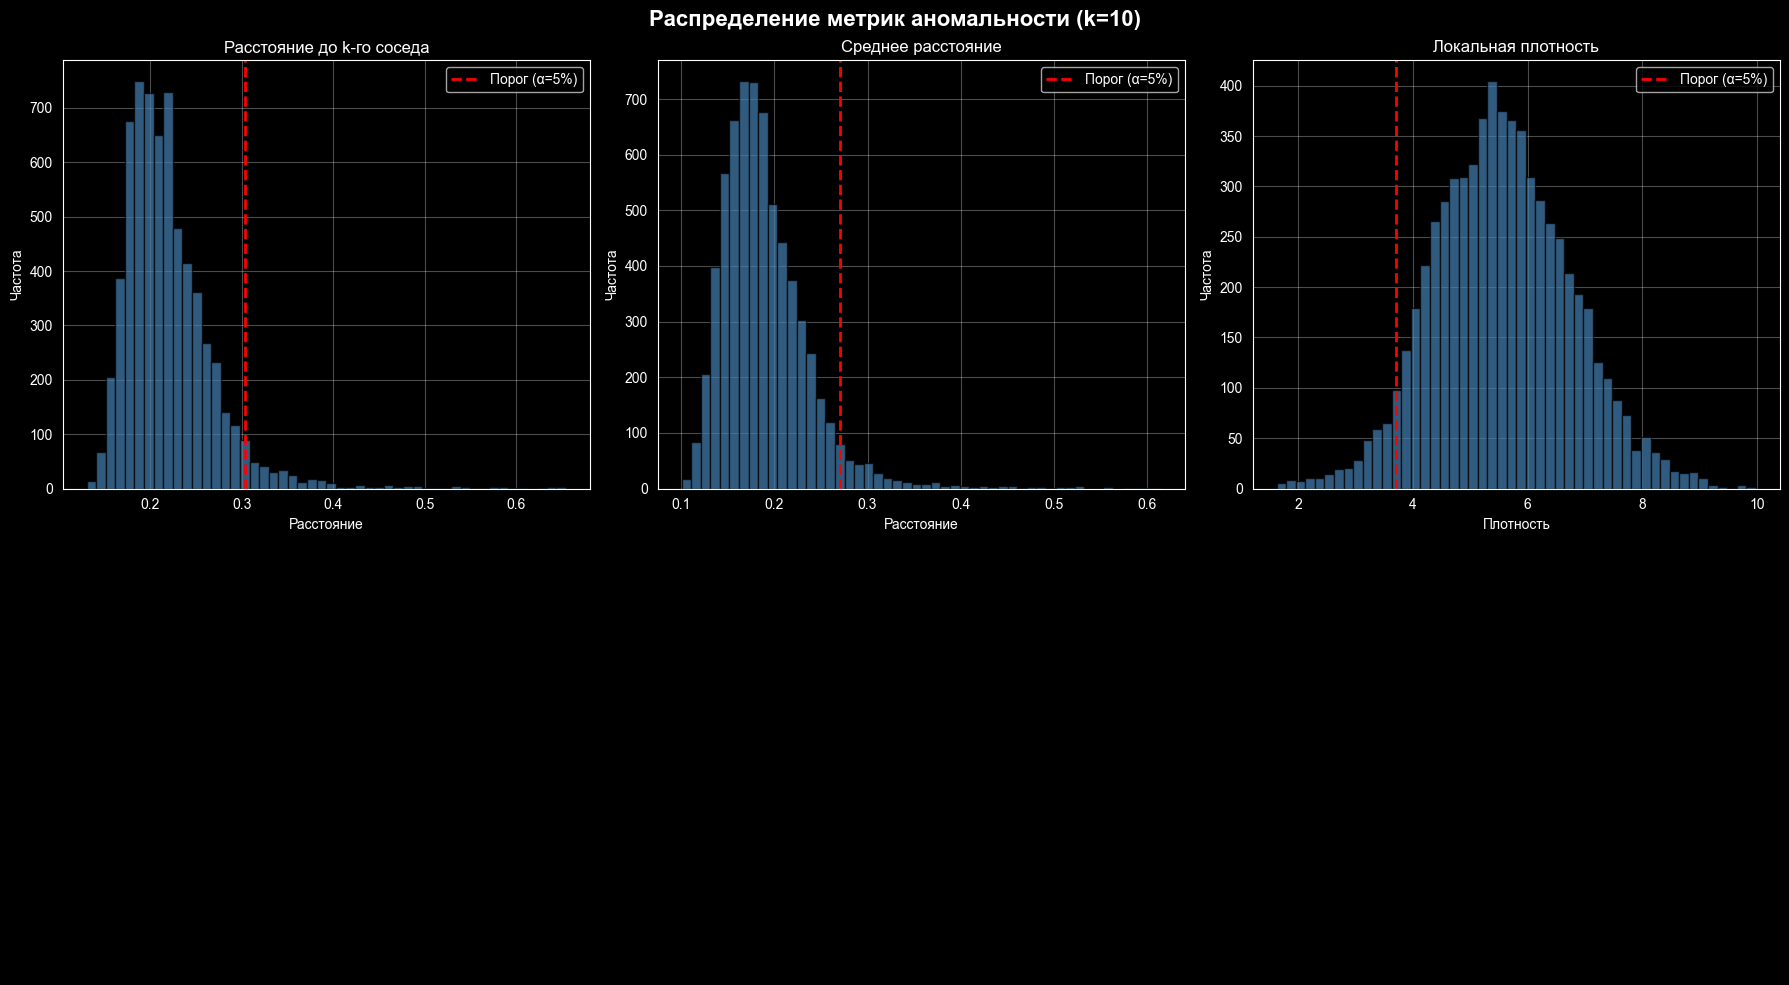

Объяснённая дисперсия PCA: 55.35%


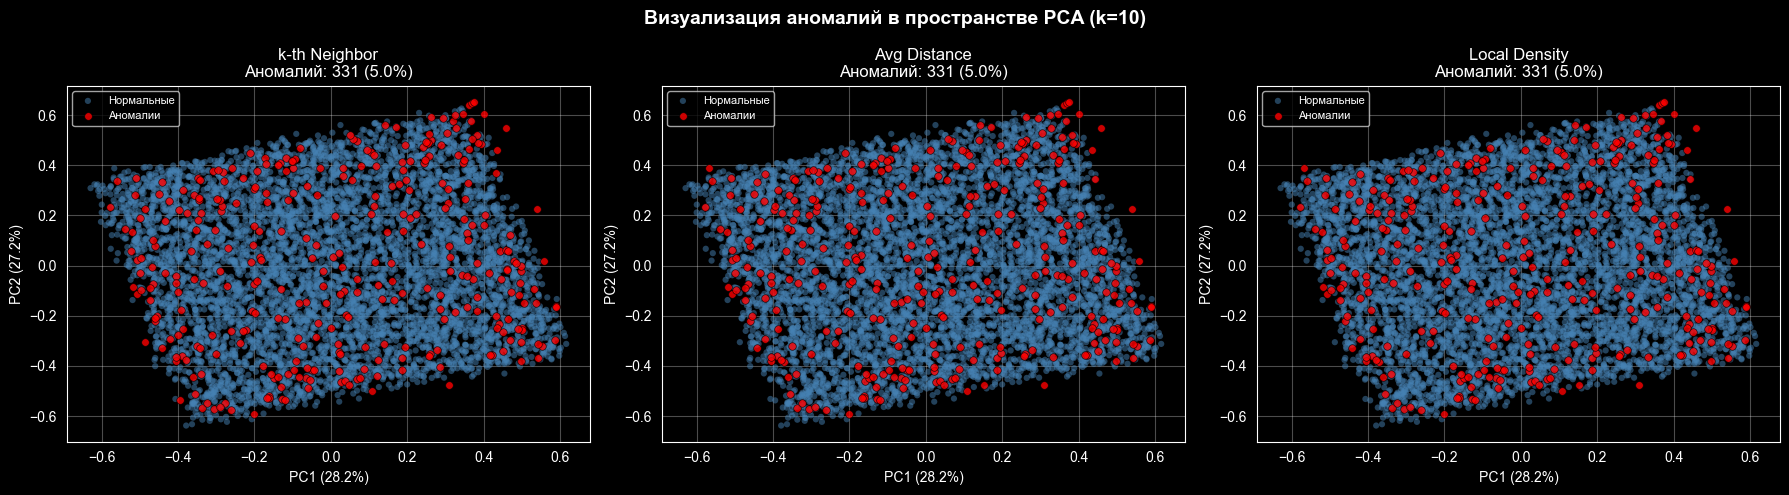


=== Анализ устойчивости по параметру k ===
k     Euclidean %     Manhattan %    
-----------------------------------
3     5.01            5.01           
5     5.01            5.01           
7     5.01            5.01           
9     5.01            5.01           
10    5.01            5.01           
15    5.01            5.01           
20    5.01            5.01           


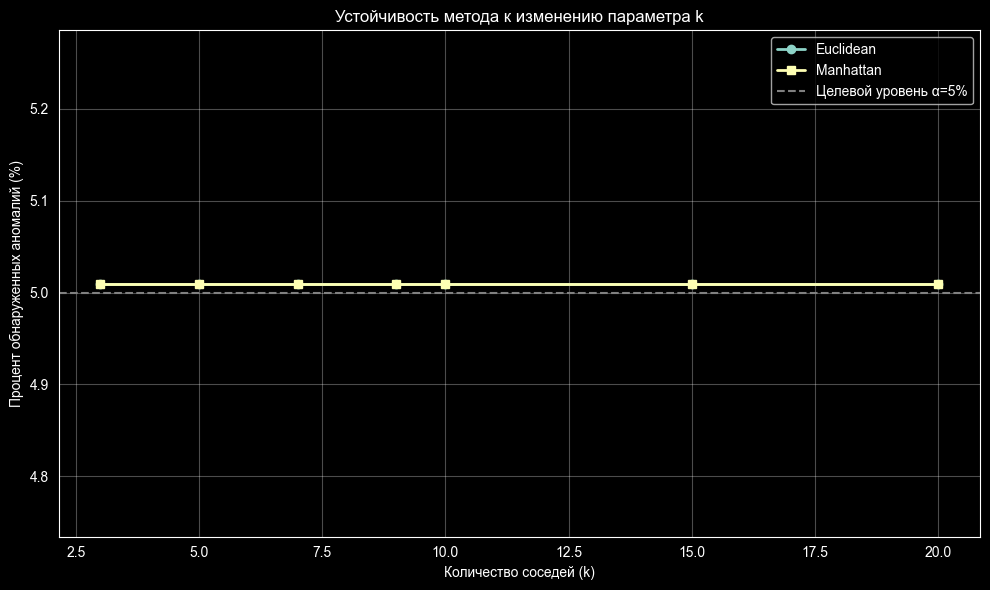


=== Сравнительная таблица методов (k=10, α=5%) ===
        Метод   Метрика  k  Аномалий Процент (%)  Порог
k-th Neighbor euclidean 10       331        5.01 0.3041
k-th Neighbor manhattan 10       331        5.01 0.5885
 Avg Distance euclidean 10       331        5.01 0.2699
 Avg Distance manhattan 10       331        5.01 0.5096
Local Density euclidean 10       331        5.01 3.7047
Local Density manhattan 10       331        5.01 1.9624


In [10]:

def kth_neighbor_anomaly_detection(X, k=10, alpha=5, metric='euclidean'):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    kth_dist = distances[:, k]
    threshold = np.percentile(kth_dist, 100 - alpha)
    outliers_mask = kth_dist > threshold
    return {
        'kth_distances': kth_dist, 'threshold': threshold,
        'outliers_mask': outliers_mask, 'outliers_count': outliers_mask.sum(),
        'outliers_percentage': outliers_mask.mean() * 100
    }

k = 10; alpha = 5
results_kth = {}
for metric in ['euclidean', 'manhattan']:
    results_kth[metric] = kth_neighbor_anomaly_detection(X_scaled, k=k, alpha=alpha, metric=metric)
    print(f"\n{metric.capitalize()} расстояние (k={k}):")
    print(f"  Порог: {results_kth[metric]['threshold']:.4f}")
    print(f"  Аномалий: {results_kth[metric]['outliers_count']} ({results_kth[metric]['outliers_percentage']:.2f}%)")


def avg_k_neighbors_anomaly_detection(X, k=10, alpha=5, metric='euclidean'):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    avg_dist = distances[:, 1:].mean(axis=1)
    threshold = np.percentile(avg_dist, 100 - alpha)
    outliers_mask = avg_dist > threshold
    return {
        'avg_distances': avg_dist, 'threshold': threshold,
        'outliers_mask': outliers_mask, 'outliers_count': outliers_mask.sum(),
        'outliers_percentage': outliers_mask.mean() * 100
    }

k_values = [5, 7, 9, 10]
results_avg = {}
print("\n=== Среднее расстояние до k соседей ===")
for k in k_values:
    for metric in ['euclidean', 'manhattan']:
        key = f"{metric}_k{k}"
        results_avg[key] = avg_k_neighbors_anomaly_detection(X_scaled, k=k, alpha=alpha, metric=metric)
        print(f"{metric} (k={k}): {results_avg[key]['outliers_count']} аномалий ({results_avg[key]['outliers_percentage']:.2f}%)")


def local_density_anomaly_detection(X, k=10, alpha=5, metric='euclidean'):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    avg_dist = distances[:, 1:].mean(axis=1)
    density = 1 / (avg_dist + 1e-10)
    threshold = np.percentile(density, alpha)
    outliers_mask = density < threshold
    return {
        'density': density, 'threshold': threshold,
        'outliers_mask': outliers_mask, 'outliers_count': outliers_mask.sum(),
        'outliers_percentage': outliers_mask.mean() * 100
    }

results_density = {}
print("\n=== Оценка локальной плотности ===")
for k in k_values:
    for metric in ['euclidean', 'manhattan']:
        key = f"{metric}_k{k}"
        results_density[key] = local_density_anomaly_detection(X_scaled, k=k, alpha=alpha, metric=metric)
        print(f"{metric} (k={k}): {results_density[key]['outliers_count']} аномалий ({results_density[key]['outliers_percentage']:.2f}%)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Распределение метрик аномальности (k=10)', fontsize=16, fontweight='bold')
metrics_data = [
    ('Расстояние до k-го соседа', results_kth['euclidean']['kth_distances'], 'euclidean'),
    ('Среднее расстояние', results_avg['euclidean_k10']['avg_distances'], 'euclidean'),
    ('Локальная плотность', results_density['euclidean_k10']['density'], 'euclidean'),
]
for idx, (title, data, metric) in enumerate(metrics_data):
    ax = axes[idx // 3, idx % 3]
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    if 'плотность' in title:
        threshold = results_density['euclidean_k10']['threshold']
        ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Порог (α={alpha}%)')
        ax.set_xlabel('Плотность')
    else:
        threshold = results_kth['euclidean']['threshold'] if 'k-го' in title else results_avg['euclidean_k10']['threshold']
        ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Порог (α={alpha}%)')
        ax.set_xlabel('Расстояние')
    ax.set_ylabel('Частота'); ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
for idx in range(3, 6): axes[idx // 3, idx % 3].axis('off')
plt.tight_layout(); plt.show()


from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Объяснённая дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Визуализация аномалий в пространстве PCA (k=10)', fontsize=14, fontweight='bold')
methods = [
    ('k-th Neighbor', results_kth['euclidean']['outliers_mask']),
    ('Avg Distance', results_avg['euclidean_k10']['outliers_mask']),
    ('Local Density', results_density['euclidean_k10']['outliers_mask']),
]
for idx, (name, mask) in enumerate(methods):
    ax = axes[idx]
    ax.scatter(X_pca[~mask, 0], X_pca[~mask, 1], c='steelblue', alpha=0.5, s=20, label='Нормальные', edgecolors='none')
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='red', alpha=0.8, s=30, label='Аномалии', edgecolors='black', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(f'{name}\nАномалий: {mask.sum()} ({mask.mean()*100:.1f}%)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


k_range = [3, 5, 7, 9, 10, 15, 20]
stability_results = {'euclidean': [], 'manhattan': []}
print("\n=== Анализ устойчивости по параметру k ===")
print(f"{'k':<5} {'Euclidean %':<15} {'Manhattan %':<15}")
print("-" * 35)
for k in k_range:
    eucl_result = avg_k_neighbors_anomaly_detection(X_scaled, k=k, alpha=alpha, metric='euclidean')
    manh_result = avg_k_neighbors_anomaly_detection(X_scaled, k=k, alpha=alpha, metric='manhattan')
    stability_results['euclidean'].append((k, eucl_result['outliers_percentage']))
    stability_results['manhattan'].append((k, manh_result['outliers_percentage']))
    print(f"{k:<5} {eucl_result['outliers_percentage']:<15.2f} {manh_result['outliers_percentage']:<15.2f}")

plt.figure(figsize=(10, 6))
plt.plot([r[0] for r in stability_results['euclidean']], [r[1] for r in stability_results['euclidean']], marker='o', label='Euclidean', linewidth=2)
plt.plot([r[0] for r in stability_results['manhattan']], [r[1] for r in stability_results['manhattan']], marker='s', label='Manhattan', linewidth=2)
plt.axhline(y=alpha, color='gray', linestyle='--', label=f'Целевой уровень α={alpha}%')
plt.xlabel('Количество соседей (k)'); plt.ylabel('Процент обнаруженных аномалий (%)')
plt.title('Устойчивость метода к изменению параметра k')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


comparison_data = []
for k in [10]:
    for method_name, results_dict in [('k-th Neighbor', results_kth), ('Avg Distance', results_avg), ('Local Density', results_density)]:
        for metric in ['euclidean', 'manhattan']:
            key = f"{metric}_k{k}" if method_name != 'k-th Neighbor' else metric
            r = results_dict[key]
            comparison_data.append({
                'Метод': method_name, 'Метрика': metric, 'k': k,
                'Аномалий': r['outliers_count'], 'Процент (%)': f"{r['outliers_percentage']:.2f}", 'Порог': f"{r['threshold']:.4f}"
            })
comparison_df = pd.DataFrame(comparison_data)
print("\n=== Сравнительная таблица методов (k=10, α=5%) ===")
print(comparison_df.to_string(index=False))

### 2 Среднее расстояние до k соседей